### 📝 Task info:
- Domain: Agriculture / Machine Learning
- Task: Farmer Subsidy Eligibility / Adoption Prediction (Classification)
- Linear / Probabilistic Algorithms: Logistic Regression (LogR), Naïve Bayes (NB)
- Non-Linear Algorithms: K-Nearest Neighbors (KNN), Support Vector Machine (SVM/SVC), Decision Tree (DT), Random Forest (RF), XGBoost (XGB)

### 🥉 Farming Type Classification → Classification

In [1]:
!pip install sqlalchemy pymysql pandas

### 💻 Code Work:

In [2]:
# Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect
from urllib.parse import quote_plus
import joblib

# Sklearn Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


### 📤 0. Data Loading (from db load tables data as pandas df)
Note: Load Validated Data

In [3]:
USER = "root"
PASSWORD = quote_plus("Annapurneswaraiah@403") 
HOST = "127.0.0.1" 
PORT = "3306"
DATABASE = "agricultural"

connection_url = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_url)

inspector = inspect(engine)
tables = inspector.get_table_names()
print("Available tables in MySQL:", tables)

if len(tables) > 0:
    table_name = tables[0] 
    print(f"\nLoading data from MySQL table: '{table_name}'...")
    df = pd.read_sql(f"SELECT * FROM `{table_name}`", con=engine)
    print(f"Success! Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
    display(df.head())
else:
    print("No tables found in database!")


Available tables in MySQL: ['agricultural_productivity', 'raw_agricultural_productivity_cleaned_v7.csv']

Loading data from MySQL table: 'agricultural_productivity'...
Success! Loaded 240,000 rows and 117 columns.


,record_id,state,lga,year,season,household_id,household_size,head_of_household_age,head_of_household_sex,head_of_household_education_level,...,group_type,access_to_improved_technologies,government_subsidy_received,subsidy_type,extension_worker_visit_last_6months,labor_hours_per_week_agriculture,hired_labor_used,women_decision_making_in_agriculture,child_labor_in_agriculture,child_labor_hours_per_week
0,1,Kebbi,Ogun_LGA_1,2018,wet,1,8,36.151305,Male,Unknown,...,No_group,0,0,None,0,20.684387,0,0,0,0.000000
1,2,Zamfara,Plateau_LGA_10,2018,wet,1,2,59.818008,Female,Unknown,...,No_group,0,0,None,1,12.296398,0,1,0,0.000000
2,3,Anambra,Rivers_LGA_9,2018,wet,1,9,57.055866,Male,Unknown,...,No_group,1,0,None,1,60.305280,0,1,1,0.412805
3,4,Sokoto,Lagos_LGA_8,2018,wet,1,6,54.137561,Female,Tertiary,...,No_group,0,0,None,0,59.165103,1,0,0,0.000000
4,5,Kebbi,Benue_LGA_4,2018,wet,1,11,57.980842,Female,Unknown,...,Association,1,0,None,0,8.739638,0,0,0,0.000000


### 1. Modeling

## 1.1. Pre-Requisites

#### 🎯 1.1.1 X & y:
- Picking y output col for Predictive Modelling & considering remaining cols are X

In [4]:
target_col = 'government_subsidy_received'

cat_cols = ['farming_system', 'head_of_household_sex']
num_cols = [
    'head_of_household_age', 
    'land_owned_hectares', 
    'fertilizer_used_kg_per_hectare',
    'goats_number', 
    'sheep_number',
    'labor_hours_per_week_agriculture',
    'total_household_income_ngn'
]

X = df[cat_cols + num_cols].copy()
y = df[target_col].copy()

print(f"Features shape X: {X.shape}")
print(f"Target shape y:   {y.shape}")
print("Target Class Distribution:\n", y.value_counts(normalize=True))


Features shape X: (240000, 9)
Target shape y:   (240000,)
Target Class Distribution:
 government_subsidy_received
0    0.750075
1    0.249925
Name: proportion, dtype: float64



### ✂️ 1.1.2 Train-Test Split:
- Dividing X & y data into train-test parts (80-20 split), train part for learning, test part for evaluation

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape, "y_test shape: ", y_test.shape)


X_train shape: (192000, 9) y_train shape: (192000,)
X_test shape:  (48000, 9) y_test shape:  (48000,)


### 🔄 1.1.3 Missing Values & Outliers Handling
- for xtrain & xtest: Missing Values & Outlier Handling
- for ytrain & ytest: Filter na data for future predictions

In [6]:
# 1. Missing Values Identification & Handling
print("Missing values in X_train:\n", X_train.isnull().sum())
print("Missing values in y_train:\n", y_train.isnull().sum())

for col in num_cols:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

for col in cat_cols:
    mod = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mod)
    X_test[col] = X_test[col].fillna(mod)




Missing values in X_train:
 farming_system                      0
head_of_household_sex               0
head_of_household_age               0
land_owned_hectares                 0
fertilizer_used_kg_per_hectare      0
goats_number                        0
sheep_number                        0
labor_hours_per_week_agriculture    0
total_household_income_ngn          0
dtype: int64
Missing values in y_train:
 0


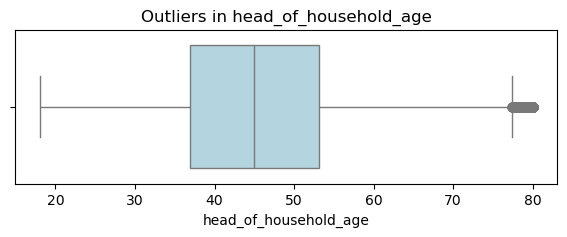

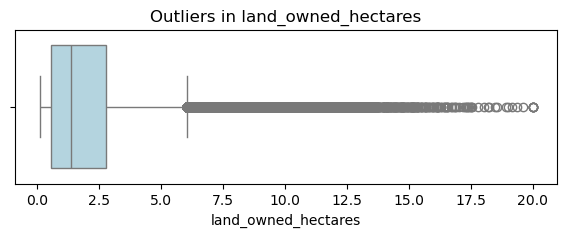

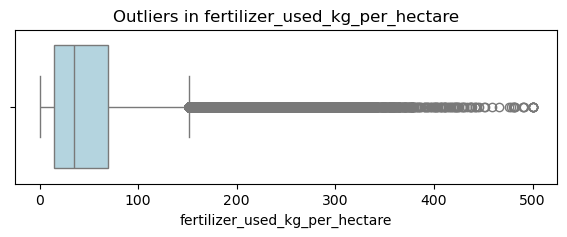

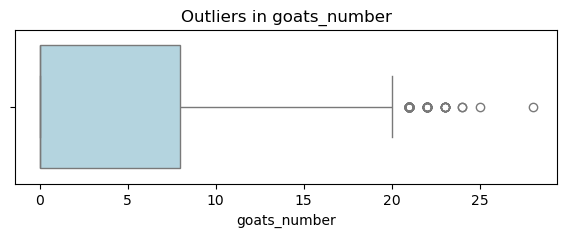

In [7]:
# 2. Outliers Visualization
for col in num_cols[:4]:
    plt.figure(figsize=(7, 2))
    sns.boxplot(x=X_train[col], color='lightblue')
    plt.title('Outliers in ' + col)
    plt.show()

### ⚙️ 1.1.4 Feature Engineering of x for y
- Feature Generation
- Feature Selection
- Feature Modification (Encoding & Scaling)

In [8]:
# 1. Feature Generation
def create_features(df_input):
    df_feat = df_input.copy()
    df_feat['total_livestock'] = df_feat['goats_number'] + df_feat['sheep_number']
    df_feat['fertilizer_per_hectare'] = df_feat['fertilizer_used_kg_per_hectare'] / (df_feat['land_owned_hectares'] + 0.01)
    df_feat['income_per_hectare'] = df_feat['total_household_income_ngn'] / (df_feat['land_owned_hectares'] + 0.01)
    df_feat['is_senior_farmer'] = np.where(df_feat['head_of_household_age'] >= 60, 1, 0)
    return df_feat

X_train_fe = create_features(X_train)
X_test_fe = create_features(X_test)

new_num_cols = num_cols + ['total_livestock', 'fertilizer_per_hectare', 'income_per_hectare', 'is_senior_farmer']

# 2. Categorical Encoding (OneHotEncoder)
cat_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = cat_encoder.fit_transform(X_train_fe[cat_cols])
X_test_cat = cat_encoder.transform(X_test_fe[cat_cols])

encoded_cat_cols = list(cat_encoder.get_feature_names_out(cat_cols))
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_cat_cols, index=X_train_fe.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_cat_cols, index=X_test_fe.index)

X_train_prep = pd.concat([X_train_fe[new_num_cols], X_train_cat_df], axis=1)
X_test_prep = pd.concat([X_test_fe[new_num_cols], X_test_cat_df], axis=1)

# 3. Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_prep)
X_test_scaled = scaler.transform(X_test_prep)

print("Preprocessed X_train shape:", X_train_scaled.shape)
print("Preprocessed X_test shape: ", X_test_scaled.shape)


Preprocessed X_train shape: (192000, 14)
Preprocessed X_test shape:  (48000, 14)


### 🤖 1.2 Model + Define, Train & Study
- Classification: LogR, KNN, NB, SVM, DT, RF, XGB
- Loading models through python sklearn module
- Training Models with train data

In [ ]:
models = {
    "LogR": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "NB": GaussianNB(),
    "SVM": SVC(C=1.0, kernel='rbf', probability=True, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGB": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"✅ Model {name} trained.")


✅ Model LogR trained.
✅ Model KNN trained.
✅ Model NB trained.


### 1.3 Trained Model Predictions & Evaluations
- Predictions on Test Data
- Checking Trained model performance with evaluation metrics & Cross-Validation
- Bias-Variance Tradeoff Analysis for All Classification Models

In [ ]:
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained_models.items():
    pred_train = model.predict(X_train_scaled)
    pred_test = model.predict(X_test_scaled)
    
    train_f1 = f1_score(y_train, pred_train, average='weighted')
    test_f1 = f1_score(y_test, pred_test, average='weighted')
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_test_score = round(cv_scores.mean(), 4)
    
    if abs(train_f1 - test_f1) <= 0.05 and train_f1 >= 0.70:
        fit_status = "Goodfit"
    elif train_f1 - test_f1 > 0.05:
        fit_status = "Overfit"
    else:
        fit_status = "Underfit"
        
    results.append({
        "Models": name,
        "TrainScore (F1)": round(train_f1, 4),
        "TestScore (F1)": round(test_f1, 4),
        "Bias-Variance (Fit)": fit_status,
        "CrossValidation (TestScore)": cv_test_score
    })

# Final Evaluation Table format matching Blueprint
eval_df = pd.DataFrame(results)
display(eval_df)


### ✨ 1.4 Hyp Param Tuning
- Improving Model/Best Model Performance further by Hyp Param Tuning

In [ ]:
# 1. Tuning Random Forest Classifier
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'criterion': ['gini', 'entropy']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

print("Best RF Params:", grid_rf.best_params_)
print("Best RF F1 Score:", round(grid_rf.best_score_, 4))

# 2. Tuning XGBoost Classifier
xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'), xgb_param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)
best_xgb = grid_xgb.best_estimator_

print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB F1 Score:", round(grid_xgb.best_score_, 4))


### 📥 1.5 Saving model & Real Time Prediction
- Saving trained, evaluated and picked best model and use it on unseen data for future predictions

In [ ]:
# Select Best Tuned Model
best_model = best_rf if grid_rf.best_score_ >= grid_xgb.best_score_ else best_xgb

# 1. Save artifacts
joblib.dump(best_model, 'best_classification_model.pkl')
joblib.dump(scaler, 'classification_scaler.pkl')
joblib.dump(cat_encoder, 'classification_encoder.pkl')
print("Best Classification Model, Scaler, and Encoder saved successfully.")

# 2. Real Time Prediction Example
sample_data = pd.DataFrame([{
    'farming_system': 'Crop',
    'head_of_household_sex': 'Male',
    'head_of_household_age': 45,
    'land_owned_hectares': 2.5,
    'fertilizer_used_kg_per_hectare': 50,
    'goats_number': 3,
    'sheep_number': 2,
    'labor_hours_per_week_agriculture': 30,
    'total_household_income_ngn': 350000
}])

sample_fe = create_features(sample_data)
sample_cat = cat_encoder.transform(sample_fe[cat_cols])
sample_cat_df = pd.DataFrame(sample_cat, columns=encoded_cat_cols, index=sample_fe.index)
sample_prep = pd.concat([sample_fe[new_num_cols], sample_cat_df], axis=1)

sample_scaled = scaler.transform(sample_prep)
pred_class = best_model.predict(sample_scaled)[0]
pred_probability = best_model.predict_proba(sample_scaled)[0][pred_class]

print(f"\nReal Time Prediction Output:")
print(f"Predicted Target ({target_col}): {pred_class}")
print(f"Prediction Probability: {pred_probability * 100:.2f}%")
